# 📊 EDA — Exploratory Data Analysis
> **Notebook 2 of 4** — Run after `01_data_generation.ipynb`.
> Explores inventory aging, revenue distribution, seasonality, and customer behaviour.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3, os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR    = "../data/generated_data"
SQL_DIR     = "../data/sql"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load CSVs
categories  = pd.read_csv(f"{DATA_DIR}/categories.csv")
products    = pd.read_csv(f"{DATA_DIR}/products.csv")
customers   = pd.read_csv(f"{DATA_DIR}/customers.csv")
rentals     = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date", "rental_end_date", "actual_return_date", "expected_return_date"])
returns     = pd.read_csv(f"{DATA_DIR}/return_conditions.csv")
events      = pd.read_csv(f"{DATA_DIR}/inventory_events.csv")
comparison  = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Time range:     {rentals['rental_start_date'].min().date()} → {rentals['rental_start_date'].max().date()}")
print(f"Categories:     {len(categories)}")
print(f"Products:       {len(products):,}")
print(f"Customers:      {len(customers):,} registered")

active_renters = rentals['customer_id'].nunique()
never_rented   = len(customers) - active_renters
print(f"  ├─ Active renters:   {active_renters:,} unique customers appear in rentals")
print(f"  └─ Never rented:     {never_rented:,} registered but never converted")
print(f"     (non-renters are real — they represent churn / drop-off pipeline)")
print(f"Rentals:        {len(rentals):,}")
print(f"Returns:        {len(returns):,}")
print(f"No-returns:     {rentals['is_no_return'].sum():,} ({rentals['is_no_return'].mean()*100:.1f}%)")
print(f"Damaged/lost:   {rentals['is_damaged_beyond_repair'].sum():,} ({rentals['is_damaged_beyond_repair'].mean()*100:.1f}%)")
print(f"Late returns:   {rentals['is_late'].sum():,} ({rentals['is_late'].mean()*100:.1f}%)")
print(f"Avg rentals/product: {rentals.groupby('product_id').size().mean():.1f}  (items wear out; late-joiners have less time)")
print("=" * 50)


DATASET SUMMARY
Time range:     2021-11-14 → 2024-12-30
Categories:     14
Products:       500
Customers:      2,000 registered
  ├─ Active renters:   1,105 unique customers appear in rentals
  └─ Never rented:     895 registered but never converted
     (non-renters are real — they represent churn / drop-off pipeline)
Rentals:        1,592
Returns:        1,501
No-returns:     91 (5.7%)
Damaged/lost:   45 (2.8%)
Late returns:   202 (12.7%)
Avg rentals/product: 3.9  (items wear out; late-joiners have less time)


## 1 · Revenue Distribution by Category

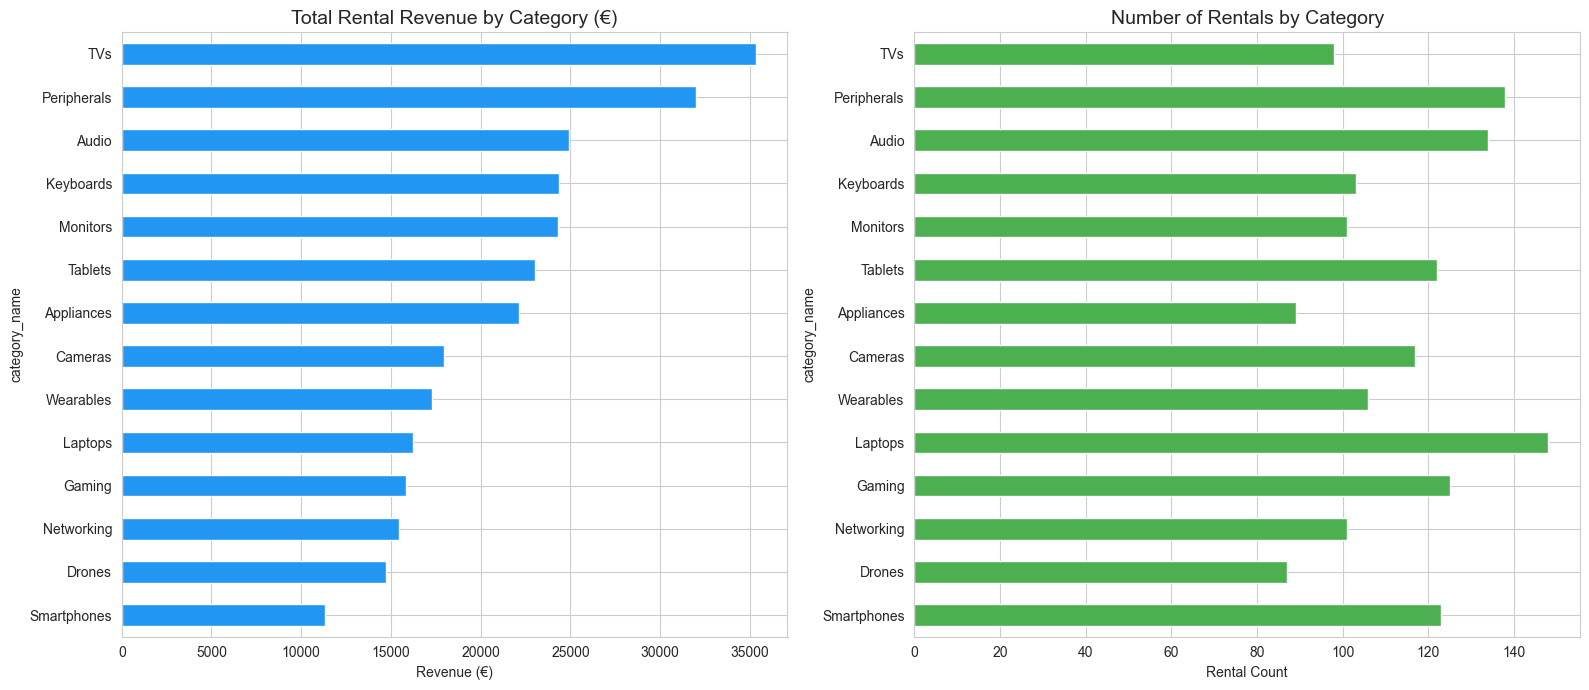

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Merge rentals with products and categories
rental_detail = rentals.merge(products[["product_id", "category_id", "original_retail_price"]], on="product_id")
rental_detail = rental_detail.merge(categories[["category_id", "category_name"]], on="category_id")

rev_by_cat = rental_detail.groupby("category_name")["total_rental_revenue"].agg(["sum", "mean", "count"])
rev_by_cat.columns = ["total_revenue", "avg_revenue", "rental_count"]
rev_by_cat = rev_by_cat.sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rev_by_cat["total_revenue"].plot(kind="barh", ax=axes[0], color="#2196F3")
axes[0].set_title("Total Rental Revenue by Category (€)", fontsize=14)
axes[0].set_xlabel("Revenue (€)")

rev_by_cat["rental_count"].plot(kind="barh", ax=axes[1], color="#4CAF50")
axes[1].set_title("Number of Rentals by Category", fontsize=14)
axes[1].set_xlabel("Rental Count")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/revenue_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Rental Timeline — Seasonal Patterns

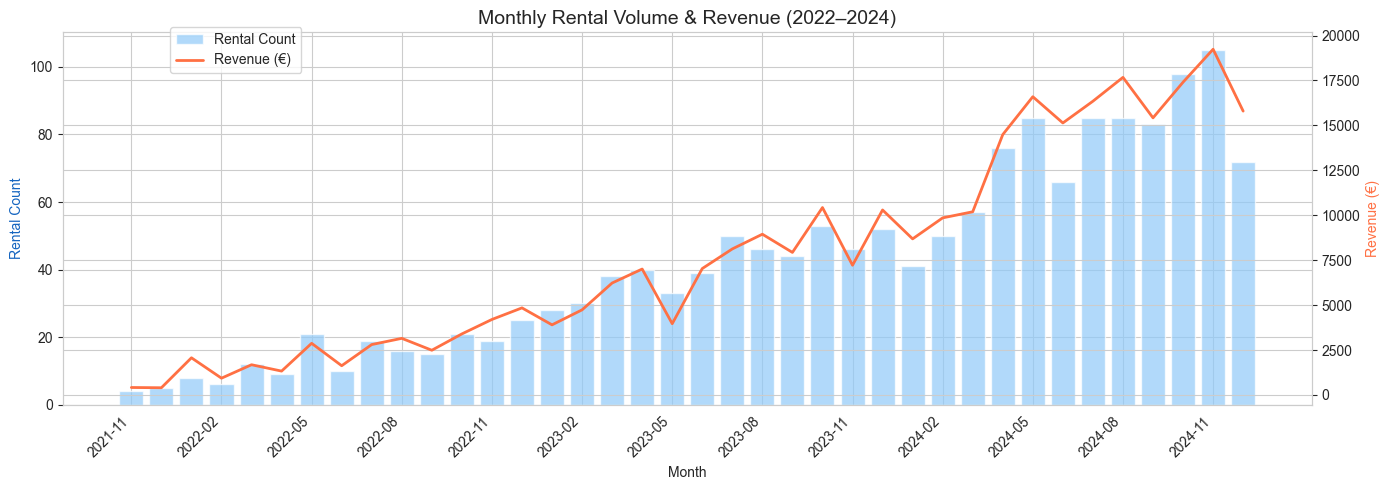

In [ ]:
rentals["rental_month"] = rentals["rental_start_date"].dt.to_period("M")
monthly = rentals.groupby("rental_month").agg(
    count=("rental_id", "count"),
    revenue=("total_rental_revenue", "sum")
).reset_index()
monthly["rental_month"] = monthly["rental_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(range(len(monthly)), monthly["count"], color="#90CAF9", alpha=0.7, label="Rental Count")
ax1.set_ylabel("Rental Count", color="#1565C0")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly["revenue"], color="#FF7043", linewidth=2, label="Revenue (€)")
ax2.set_ylabel("Revenue (€)", color="#FF7043")

ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly["rental_month"].iloc[::3], rotation=45, ha="right")
ax1.set_title("Monthly Rental Volume & Revenue (2022–2024)", fontsize=14)

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/monthly_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Customer Segmentation

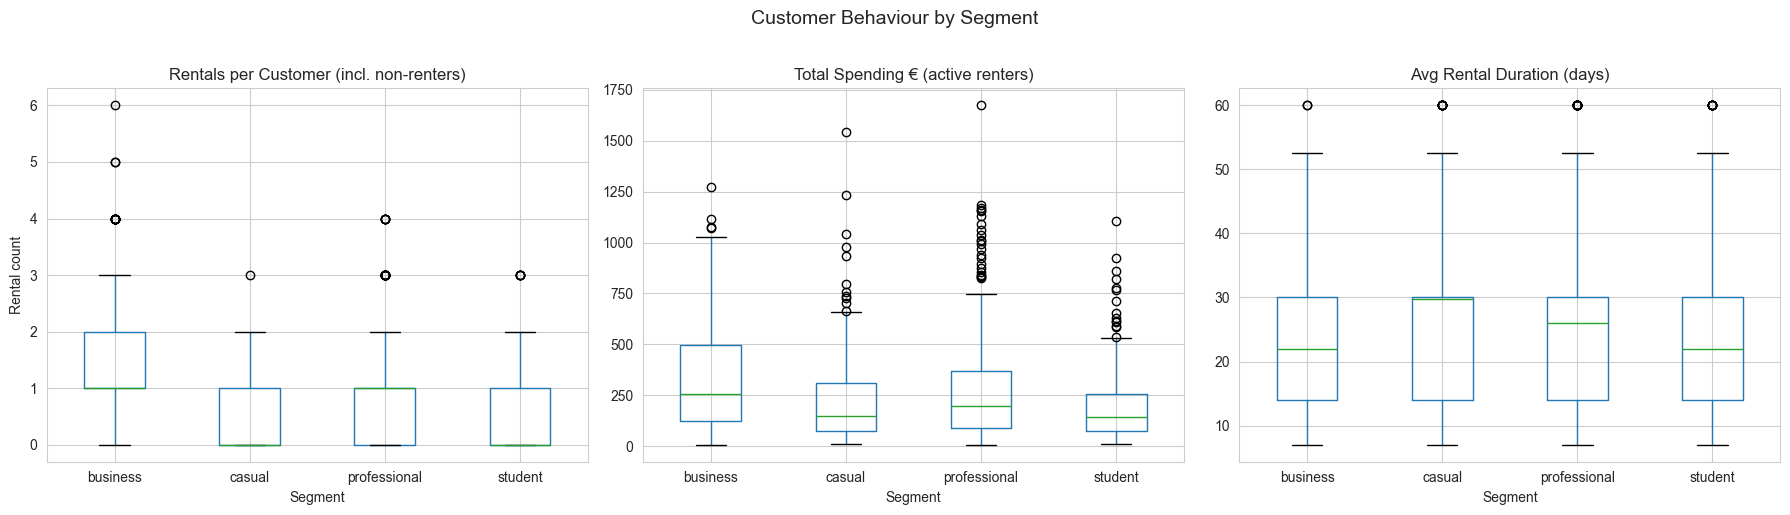

In [ ]:
# Merge rental counts with customer segments
cust_rentals = rentals.groupby("customer_id").agg(
    total_rentals=("rental_id", "count"),
    total_spent=("total_rental_revenue", "sum"),
    avg_duration=("rental_duration_days", "mean")
).reset_index()
cust_rentals = cust_rentals.merge(customers[["customer_id", "customer_segment", "city"]], on="customer_id")

# Include never-rented customers (show them as 0 rentals)
all_customers = customers[["customer_id", "customer_segment"]].merge(
    cust_rentals[["customer_id", "total_rentals"]], on="customer_id", how="left"
).fillna({"total_rentals": 0})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rentals per customer by segment (including 0s)
all_customers.boxplot(column="total_rentals", by="customer_segment", ax=axes[0])
axes[0].set_title("Rentals per Customer (incl. non-renters)", fontsize=12)
axes[0].set_xlabel("Segment"); axes[0].set_ylabel("Rental count")

# Total spending — active renters only
cust_rentals.boxplot(column="total_spent", by="customer_segment", ax=axes[1])
axes[1].set_title("Total Spending € (active renters)", fontsize=12)
axes[1].set_xlabel("Segment")

# Avg rental duration
cust_rentals.boxplot(column="avg_duration", by="customer_segment", ax=axes[2])
axes[2].set_title("Avg Rental Duration (days)", fontsize=12)
axes[2].set_xlabel("Segment")

plt.suptitle("Customer Behaviour by Segment", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · Inventory Aging — The Dead Zone

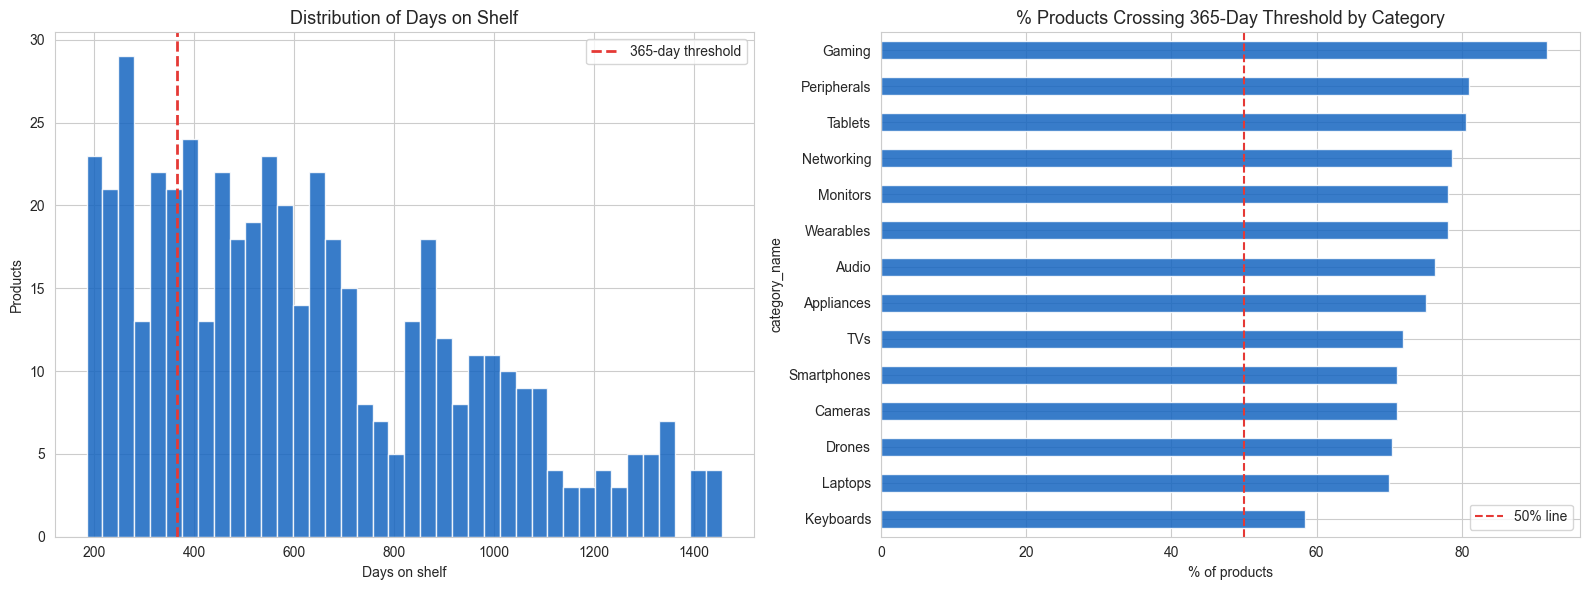

In [ ]:
# Products that crossed the 365-day threshold (the case for rental eligibility)
products_copy = products.copy()
products_copy["listed_date"] = pd.to_datetime(products_copy["listed_date"])
products_copy["days_on_shelf"] = (pd.Timestamp("2024-12-31") - products_copy["listed_date"]).dt.days
products_copy = products_copy.merge(categories[["category_id", "category_name"]], on="category_id")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of days on shelf
axes[0].hist(products_copy["days_on_shelf"], bins=40, color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].axvline(x=365, color="#E53935", linestyle="--", linewidth=2, label="365-day threshold")
axes[0].set_title("Distribution of Days on Shelf", fontsize=13)
axes[0].set_xlabel("Days on shelf"); axes[0].set_ylabel("Products")
axes[0].legend()

# % crossing 365-day threshold by category
over_365 = products_copy.groupby("category_name").apply(
    lambda x: (x["days_on_shelf"] >= 365).mean() * 100
).sort_values(ascending=True)
over_365.plot(kind="barh", ax=axes[1], color="#1565C0", alpha=0.85)
axes[1].axvline(x=50, color="#E53935", linestyle="--", linewidth=1.5, label="50% line")
axes[1].set_title("% Products Crossing 365-Day Threshold by Category", fontsize=13)
axes[1].set_xlabel("% of products"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/inventory_aging.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · Price Depreciation Over Time

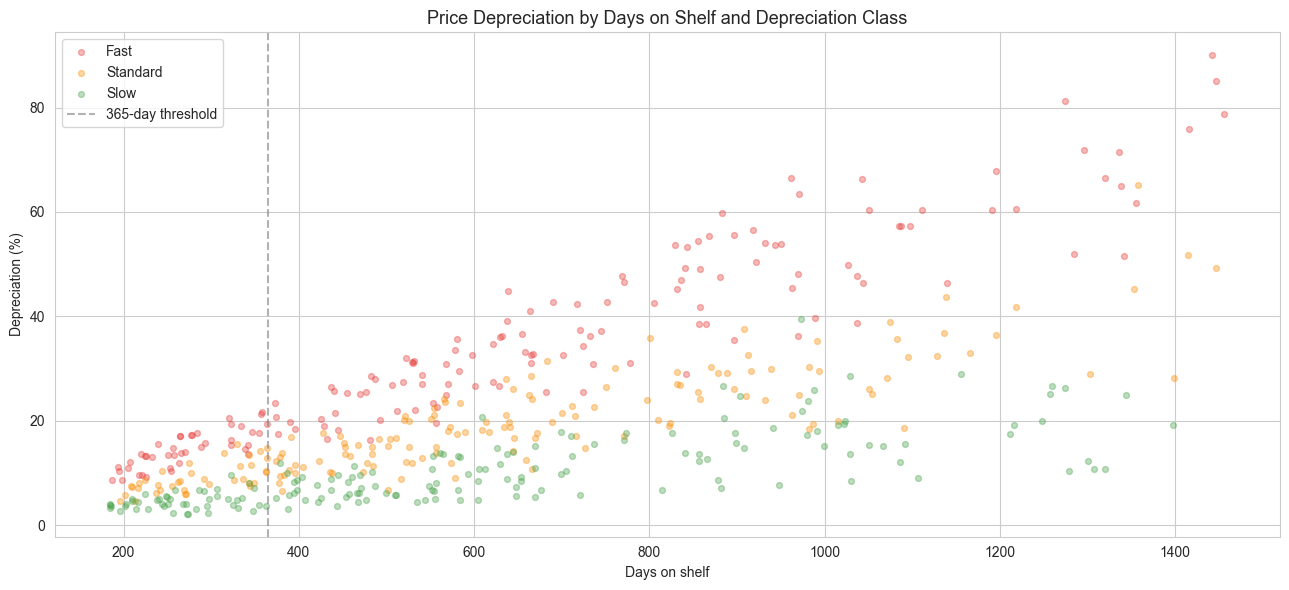

In [ ]:
products_copy["depreciation_pct"] = (
    (products_copy["original_retail_price"] - products_copy["current_depreciated_value"])
    / products_copy["original_retail_price"] * 100
)
dep_class = products_copy.merge(categories[["category_id", "depreciation_class"]], on="category_id", suffixes=("", "_c"))

fig, ax = plt.subplots(figsize=(13, 6))
for dep, color in [("fast", "#E53935"), ("standard", "#FB8C00"), ("slow", "#43A047")]:
    subset = dep_class[dep_class["depreciation_class"] == dep]
    ax.scatter(subset["days_on_shelf"], subset["depreciation_pct"],
               alpha=0.35, s=18, color=color, label=dep.capitalize())

ax.axvline(x=365, color="gray", linestyle="--", alpha=0.6, label="365-day threshold")
ax.set_xlabel("Days on shelf"); ax.set_ylabel("Depreciation (%)")
ax.set_title("Price Depreciation by Days on Shelf and Depreciation Class", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/price_depreciation.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Rental Win Rate — First Look at the Hypothesis

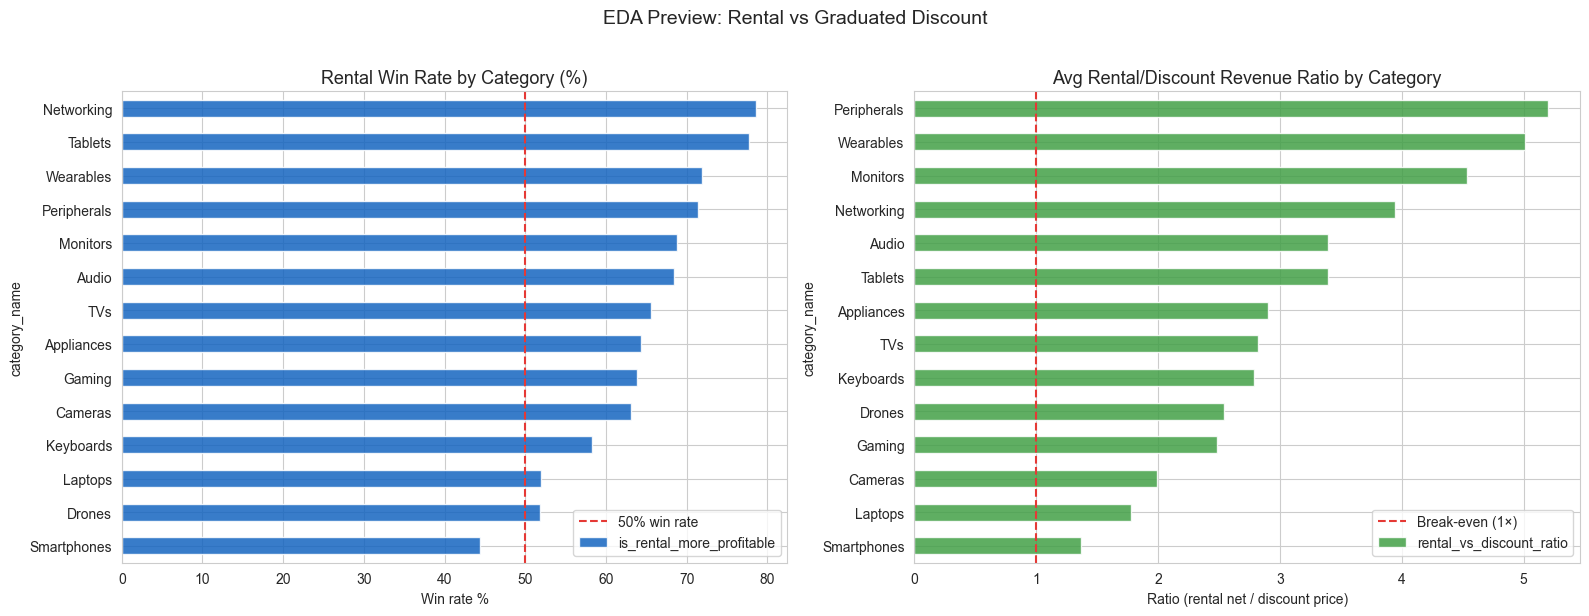

Overall rental win rate: 63.6%
Overall avg ratio:       3.08×
→ Full analysis in 03_ab_testing.ipynb


In [ ]:
win_by_cat = comparison.merge(
    products[["product_id", "category_id"]], on="product_id"
).merge(categories[["category_id", "category_name"]], on="category_id")

win_rate = win_by_cat.groupby("category_name")["is_rental_more_profitable"].mean().sort_values() * 100
avg_ratio = win_by_cat.groupby("category_name")["rental_vs_discount_ratio"].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

win_rate.plot(kind="barh", ax=axes[0], color="#1565C0", alpha=0.85)
axes[0].axvline(x=50, color="#E53935", linestyle="--", linewidth=1.5, label="50% win rate")
axes[0].set_title("Rental Win Rate by Category (%)", fontsize=13)
axes[0].set_xlabel("Win rate %"); axes[0].legend()

avg_ratio.sort_values().plot(kind="barh", ax=axes[1], color="#43A047", alpha=0.85)
axes[1].axvline(x=1, color="#E53935", linestyle="--", linewidth=1.5, label="Break-even (1×)")
axes[1].set_title("Avg Rental/Discount Revenue Ratio by Category", fontsize=13)
axes[1].set_xlabel("Ratio (rental net / discount price)"); axes[1].legend()

plt.suptitle("EDA Preview: Rental vs Graduated Discount", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/win_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

overall_win = comparison["is_rental_more_profitable"].mean() * 100
overall_ratio = comparison["rental_vs_discount_ratio"].mean()
print(f"Overall rental win rate: {overall_win:.1f}%")
print(f"Overall avg ratio:       {overall_ratio:.2f}×")
print("→ Full analysis in 03_ab_testing.ipynb")


---
## ✅ EDA Deliverables

| Chart | File |
|---|---|
| Revenue distribution by category | `revenue_by_category.png` |
| Monthly rental timeline / seasonality | `seasonal_patterns.png` |
| Customer behaviour by segment | `customer_segments.png` |
| Inventory aging — days on shelf | `inventory_aging.png` |
| Price depreciation scatter | `price_depreciation.png` |
| Win rate & ratio preview by category | `win_rate_by_category.png` |

**→ Proceed to `03_ab_testing.ipynb`**